# UTSA CS 3793: Assignment-3

**Figueroa - Fabian - (sop310)**






## Learning Objectives

Implement 2 different machine learning algorithms
*   Stochastic Gradient Descent
*   ID3 Decision Tree



## Description

This assignment is focused on **machine learning**, mainly on the implementation of 2 different algorithms - Stochastic Gradient Descent & ID3 decision tree.
The assignment is divided into two sections, each for one unique ML algorithm.

The base structure and comments are provided on what should be done. You can use some libraries that help support you for the successful completion of the assignment. However, you **CANNOT** use a complete library that contains the implementation of ML algorithms. You can get pieces of code from online, but please cite the source properly.


##Import Libraries

Write all the import statements here. This should be for both algorithm implmentations. As mentioned before, you can not use any premade ML libraries.

In [1]:
# import all required libraries
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
# import os

In [2]:
# Assume that the data files are in the following folder -- THIS WILL BE USED BY THE TA
basePath = "/content/drive/My Drive/Colab Notebooks/Artificial Intelligence/Data/"



#Stochastic Gradient Descent

In this section, you will implement the Stochastic Gradient Descent algorithm. The training is for a **binary classification** task i.e. each instance will have a class value of 0 or 1. Also, assume that you are given **all binary-valued attributes** and that there are **no missing values** in the train or test data.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
# print(os.listdir(basePath))

Mounted at /content/drive


##Algorithm

(40 points)

Following are the data files that will be provided to you for the gradient descent algorithm implementation.

*   Training file - 'gd-train.dat'
*   Testing file - 'gd-test.dat'

In these files, only non-space characters are relevant. The first line contains the attribute names. All the other lines are different example instances to be used for the algorithm. Each column holds values of the attributes, whereas the last column holds the class label for that instance.

Write the code in the following code block, structure is provided. Instructions on the steps to follow are provided as comments.



In [4]:
# Data file name variables
train = basePath + "gd-train.dat"
test = basePath + "gd-test.dat"


In [5]:
# checking data values
'''
with open(train, "r") as f:
  for i, line in enumerate(f):
    print(repr(line))
    if i > 5:
      break
print()
with open(test, "r") as f:
  for i, line in enumerate(f):
    print(repr(line))
    if i > 5:
      break
'''
# Read the training and testing data files
train_df = pd.read_csv(train, sep="\t")
test_df = pd.read_csv(test, sep="\t")


In [6]:
# Activation Function - implement Sigmoid
def activation_function(h):
    # given 'h' compute and return 'z' based on the activation function implemented
    z = 1 / (1 + np.exp(-h))
    return z



In [7]:
# Train the model using the given training dataset and the learning rate
# return the "weights" learnt for the perceptron - include the weight assocaited with bias as the last entry
def train(train_data, learning_rate=0.05):
    # initialize weights to 0
    y = train_data["C"]
    X = train_data.drop(columns="C")
    X["bias"] = 1
    w = np.zeros(X.shape[1])

    # go through each training data instance
        # get 'x' as one multi-variate data instance and 'y' as the ground truth class label
        # obtain h(x)
        # call the activation function with 'h' as parameter to obtain 'z'
        # update all weights individually using learning_rate, (y-z), and the corresponding 'x'
    for idx, x_row in X.iterrows():
      y_true = y[idx]
      x = x_row.to_numpy()
      h = np.dot(w, x)
      z = activation_function(h)
      w = w + learning_rate * (y_true - z) * x
    # return the final learnt weights
    return w

# print(train(train_df))

In [8]:
# Test the model (weights learnt) using the given test dataset
# return the accuracy value
def test(test_data, weights, threshold):
  y = test_data["C"]
  X = test_data.drop(columns="C")
  X["bias"] = 1
    # go through each testing data instance
        # get 'x' as one multi-variate data instance and 'y' as the ground truth class label
        # obtain h(x)
        # call the activation function with 'h' as parameter to obtain 'z'
        # use 'threshold' to convert 'z' to either 0 or 1 so as to match to the ground truth binary labels
        # compare the thresholded 'z' with 'y' to calculate the positive and negative instances for calculating accuracy
  correct_cnt = 0
  for idx, x_row in X.iterrows():
    y_true = y[idx]
    x = x_row.to_numpy()
    h = np.dot(weights, x)
    z = activation_function(h)
    if z >= threshold:
      prediction = 1
    else:
      prediction = 0
    if prediction == y_true:
      correct_cnt+=1
  accuracy = correct_cnt / X.shape[0]
    # return the accuracy value for the given test dataset
  return accuracy


In [9]:
# Gradient Descent function
def gradient_descent(df_train, df_test, learning_rate=0.05, threshold=0.5):
    # call the train function to train the model and obtain the weights
    w = train(df_train, learning_rate)
    # call the test function with the training dataset to obtain the training accuracy
    trainAccuracy = test(df_train, w, threshold)
    # call the test function with the testing dataset to obtain the testing accuracy
    testAccuracy = test(df_test, w, threshold)
    # return (trainAccuracy, testAccuracy)
    return (trainAccuracy, testAccuracy)


In [10]:
# Threshold of 0.5 will be used to classify the instance for the test. If the value is >= 0.5, classify as 1 or else 0.
threshold = 0.5


In [11]:
# Main algorithm loop
# Loop through all the different learning rates [0.05, 1]
    # For each learning rate selected, call the gradient descent function to obtain the train and test accuracy values
    # Print both the accuracy values as "Accuracy for LR of 0.1 on Training set = x %" OR "Accuracy for LR of 0.1 on Testing set = x %"
learning_rates = np.arange(0.05, 1.05, 0.05)
train_accs = []
test_accs = []

for lr in learning_rates:
  trainAcc, testAcc = gradient_descent(train_df, test_df, learning_rate=lr, threshold=threshold)
  train_accs.append(trainAcc)
  test_accs.append(testAcc)
  print(f"Accuracy for LR of {lr} on Training set = {trainAcc * 100}%")
  print(f"Accuracy for LR of {lr} on Testing set = {testAcc * 100}%")

Accuracy for LR of 0.05 on Training set = 77.0%
Accuracy for LR of 0.05 on Testing set = 70.0%
Accuracy for LR of 0.1 on Training set = 78.5%
Accuracy for LR of 0.1 on Testing set = 76.0%
Accuracy for LR of 0.15000000000000002 on Training set = 78.0%
Accuracy for LR of 0.15000000000000002 on Testing set = 75.0%
Accuracy for LR of 0.2 on Training set = 78.75%
Accuracy for LR of 0.2 on Testing set = 73.0%
Accuracy for LR of 0.25 on Training set = 76.25%
Accuracy for LR of 0.25 on Testing set = 72.0%
Accuracy for LR of 0.3 on Training set = 75.25%
Accuracy for LR of 0.3 on Testing set = 73.0%
Accuracy for LR of 0.35000000000000003 on Training set = 75.0%
Accuracy for LR of 0.35000000000000003 on Testing set = 71.0%
Accuracy for LR of 0.4 on Training set = 74.25%
Accuracy for LR of 0.4 on Testing set = 71.0%
Accuracy for LR of 0.45 on Training set = 74.25%
Accuracy for LR of 0.45 on Testing set = 72.0%
Accuracy for LR of 0.5 on Training set = 74.0%
Accuracy for LR of 0.5 on Testing set = 7

##Extra Credit - Accuracy Plots

(05 points)

Use the above accuracy results on the training and testing data and write code to plot the graphs as mentioned in the code block below.



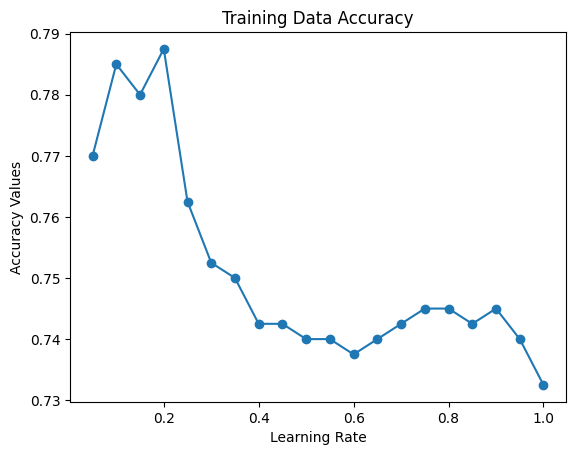

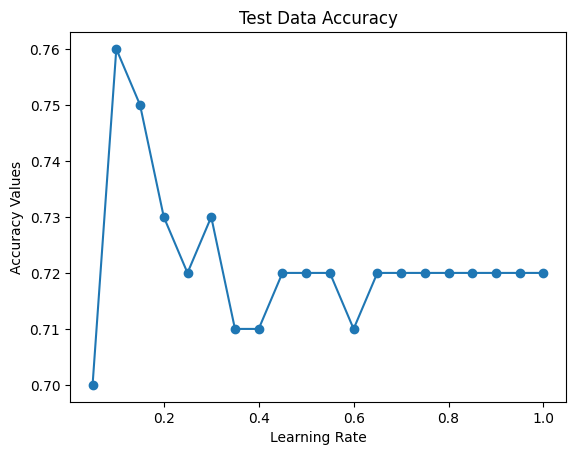

In [12]:
# Plot the graphs for accuracy results.
# There will be 2 graphs - one for training data and the other for testing data
# For each graph,
    # X-axis will be the learning rate going from 0.05-1 in increments on 0.05
    # Y-axis will be the accuracy values at the selected learning rate.

plt.figure()
plt.plot(learning_rates, train_accs, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy Values")
plt.title("Training Data Accuracy")
plt.show()

plt.figure()
plt.plot(learning_rates, test_accs, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy Values")
plt.title("Test Data Accuracy")
plt.show()

#ID3 Decision Tree

In this section, you will implement the ID3 Decision Tree algorithm. The training is for a **binary classification** task i.e. each instance will have a class value of 0 or 1. Also, assume that there are **no missing values** in the train or test data.


## Algorithm

(85 points)

Following are the data files that will be provided to you for the ID3 algorithm implementation.

*   Training file - 'id3-train.dat'
*   Testing file - 'id3-test.dat'

In these files, only non-space characters are relevant. The first line contains the attribute names. All the other lines are example instances to be used for the algorithm. Each column holds values of the attributes, whereas the last column holds the class label for that instance.

In a decision tree, if you reach a leaf node but still have examples that belong to different classes, then choose the most frequent class (among the instances at the leaf node). If you reach a leaf node in the decision tree and have no examples left or the examples are equally split among multiple classes, then choose the class that is most frequent in the entire training set. You do not need to implement pruning. Also, don’t forget to use logarithm base 2 when computing entropy and set (0 log 0) to 0.

Write the code in the following code block, structure is provided. Instructions on the steps to follow are provided as comments. The code should output the following 3 things:

*   Print the Decision Tree created, in the following example format:

    ```
    attr1 = 0 :
        attr2 = 0 :
            attr3 = 0 : 1 -- 4
            attr3 = 1 : 0 -- 9
        attr2 = 1 :
            attr4 = 0 : 0 -- 2
            attr4 = 1 : 1 -- 10
    attr1 = 1 :
        attr2 = 1 : 1 -- 17

    ```

*   Accuracy on the Training data = x %
*   Accuracy on the Test data = x %





In [13]:
# Data file name variables
train = basePath + "id3-train.dat"
test = basePath + "id3-test.dat"

train_df = pd.read_csv(train, sep="\t")
test_df = pd.read_csv(test, sep="\t")
print(train_df.columns)

Index(['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'class'], dtype='object')


In [14]:
# entropy helper function
def entropy(labels):
  counts = labels.value_counts()
  total = len(labels)

  p0 = counts.get(0,0) / total
  p1 = counts.get(1,0) / total

  term0 = 0 if p0 == 0 else -p0 * math.log2(p0)
  term1 = 0 if p1 == 0 else -p1 * math.log2(p1)

  return term0 + term1

In [15]:
# information gain helper function
def information_gain(data, attr):
  total_entropy = entropy(data["class"])
  total = len(data)

  weighted_entropy = 0
  for i in [0,1]:
    subset = data[data[attr] == i]
    if len(subset) > 0:
      weight = len(subset) / total
      weighted_entropy += weight * entropy(subset["class"])

  gain = total_entropy - weighted_entropy
  return gain

print(information_gain(train_df, "attr1"))

0.02157915316085357


In [16]:
# Pseudocode for the ID3 algorithm. Use this to create function(s).
# def ID3(data, root, attributesRemaining):
    # If you reach a leaf node in the decision tree and have no examples left or the examples are equally split among multiple classes
        # Choose and the class that is most frequent in the entire training set and return the updated tree
    # If all the instances have only one class label
        # Make this as the leaf node and use the label as the class value of the node and return the updated tree
    # If you reached a leaf node but still have examples that belong to different classes (there are no remaining attributes to be split)
        # Assign the most frequent class among the instances at the leaf node and return the updated tree
    # Find the best attribute to split by calculating the maximum information gain from the attributes remaining by calculating the entropy
    # Split the tree using the best attribute and recursively call the ID3 function using DFS to fill the sub-tree
    # return the root as the tree
def ID3(data, attributesRemaining, most_frequent_class):
  counts = data["class"].value_counts()

  count0 = counts.get(0,0)
  count1 = counts.get(1,0)

  # base case 1: no examples left, or a tie between classes
  if len(data) == 0 or (count0 > 0 and count1 > 0 and count0 == count1):
    return (most_frequent_class, len(data))
  elif count0 == 0:
    return (1, count1)
  elif count1 == 0:
    return (0, count0)
  elif len(attributesRemaining) == 0:
    if count0 > count1:
      return (0, count0)
    else:
      return (1, count1)

  best_attr = None
  best_gain = -1

  for attr in attributesRemaining:
    gain = information_gain(data, attr)
    if gain > best_gain:
      best_gain = gain
      best_attr = attr

  new_attrs = []
  for a in attributesRemaining:
    if a != best_attr:
      new_attrs.append(a)

  subset_0 = data[data[best_attr] == 0]
  subset_1 = data[data[best_attr] == 1]

  left_subtree = ID3(subset_0, new_attrs, most_frequent_class)
  right_subtree = ID3(subset_1, new_attrs, most_frequent_class)

  tree = {
    "attribute": best_attr,
    "branches": {
        0: left_subtree,
        1: right_subtree
    }
  }
  return tree

In [17]:
# print_tree helper function
def print_tree(node, depth):
  for value, child in node["branches"].items():
    prefix = "    " * depth + f"{node['attribute']} = {value} :"
    if isinstance(child, tuple):
      label, count = child
      print(f"{prefix} {label} -- {count}")
    else:
      print(prefix)
      print_tree(child, depth + 1)

# predict helperfunction
def predict(row, node):
  if isinstance(node, tuple):
    label, count = node
    return label
  else:
    attr = node["attribute"]
    value = row[attr]
    child = node["branches"][value]
    return predict(row, child)

In [18]:
# calculate_accuracy helper function
def calculate_accuracy(tree, data):
  correct_cnt = 0
  for idx, row in data.iterrows():
    y_true = row["class"]
    prediction = predict(row, tree)
    if prediction == y_true:
      correct_cnt += 1
  accuracy = correct_cnt / len(data)
  return accuracy

In [19]:
# Following is the base code structure. Feel free to change the code structure as you see fit, maybe even create more functions.

# Read the first line in the training data file, to get the number of attributes
# Read all the training instances and the ground truth class labels.
# Create the decision tree by implementing the ID3 algorithm. Pseudocode provided above.
# Print the tree in the example format mentioned.
# Use the above created tree to predict the training data and print the accuracy as "Accuracy on the Training data = x %"
    # For each training instance, predict the output label
    # Compare it with the ground truth class label and calculate the accuracy accordingly
# Use the above created tree to predict the testing data and print the accuracy as "Accuracy on the Test data = x %"
    # For each testing instance, predict the output label
    # Compare it with the ground truth class label and calculate the accuracy accordingly
most_frequent_class = train_df["class"].value_counts().index[0]
attributesRemaining = list(train_df.columns[:-1])
tree = ID3(train_df, attributesRemaining, most_frequent_class)

print_tree(tree, 0)

# predict on training data, print accuracy
train_accuracy = calculate_accuracy(tree, train_df)
print(f"Accuracy on the Training data = {train_accuracy * 100}%")

# predict on testing data, print accuracy
test_accuracy = calculate_accuracy(tree, test_df)
print(f"Accuracy on the Test data = {test_accuracy * 100}%")

attr5 = 0 :
    attr6 = 0 :
        attr2 = 0 :
            attr1 = 0 :
                attr4 = 0 :
                    attr3 = 0 : 0 -- 8
                    attr3 = 1 : 0 -- 9
                attr4 = 1 :
                    attr3 = 0 : 0 -- 12
                    attr3 = 1 : 0 -- 13
            attr1 = 1 :
                attr4 = 0 :
                    attr3 = 0 : 0 -- 14
                    attr3 = 1 : 0 -- 10
                attr4 = 1 : 0 -- 30
        attr2 = 1 :
            attr4 = 0 :
                attr3 = 0 : 0 -- 25
                attr3 = 1 :
                    attr1 = 0 : 0 -- 11
                    attr1 = 1 : 0 -- 16
            attr4 = 1 :
                attr1 = 0 :
                    attr3 = 0 : 0 -- 9
                    attr3 = 1 : 0 -- 15
                attr1 = 1 :
                    attr3 = 0 : 0 -- 8
                    attr3 = 1 : 0 -- 13
    attr6 = 1 :
        attr4 = 0 :
            attr2 = 0 :
                attr3 = 0 :
                    attr1 = 0 : 

##Extra Credit - Learning Curve

(05 points)

Instead of taking the entire training data (all 800 instances), loop through to select 'x' instances in the increments of 40 (i.e. 40, 80, 120, and so on). For each selected number 'x', randomly pick the example instances from the training data and call the ID3 function to create the decision tree. Calculate the accuracy of the created ID3 tree on the Test data file. Plot the corresponding graph, aka Learning Curve.


Accuracy for 40 training instances on Testing data = 0.7438423645320197
Accuracy for 80 training instances on Testing data = 0.7438423645320197
Accuracy for 120 training instances on Testing data = 0.7684729064039408
Accuracy for 160 training instances on Testing data = 0.7931034482758621
Accuracy for 200 training instances on Testing data = 0.7980295566502463
Accuracy for 240 training instances on Testing data = 0.8719211822660099
Accuracy for 280 training instances on Testing data = 0.8472906403940886
Accuracy for 320 training instances on Testing data = 0.8423645320197044
Accuracy for 360 training instances on Testing data = 0.8226600985221675
Accuracy for 400 training instances on Testing data = 0.8522167487684729
Accuracy for 440 training instances on Testing data = 0.8472906403940886
Accuracy for 480 training instances on Testing data = 0.8719211822660099
Accuracy for 520 training instances on Testing data = 0.8719211822660099
Accuracy for 560 training instances on Testing data =

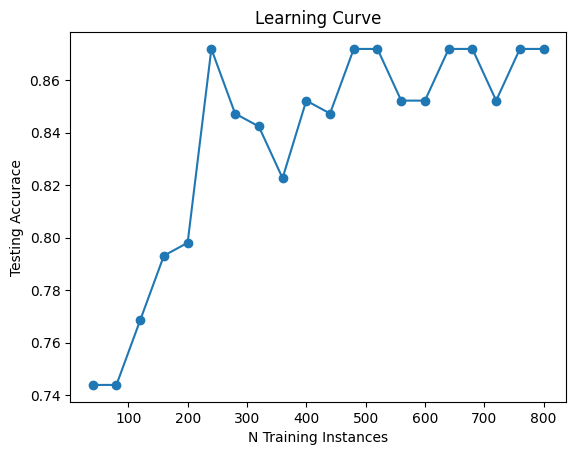

In [21]:
# Loop through to select the number of instances 'x' in increments of 40
# For each 'x',
    # Randomly select 'x' instances
    # Create the ID3 decision tree using those instances
    # Calculate the accuracy of the ID3 tree created on the Test data
n = len(train_df)
x_values = list(range(40, n + 40, 40))  # 40, 80, ..., up to n (assuming n is a multiple of 40)
test_accuracies = []

for x in x_values:
    sample = train_df.sample(n=x)
    attributesRemaining = list(train_df.columns[:-1])
    sample_tree = ID3(sample, attributesRemaining, most_frequent_class)
    acc = calculate_accuracy(sample_tree, test_df)
    test_accuracies.append(acc)
    print(f"Accuracy for {x} training instances on Testing data = {acc}")

# Plot the learning curve using the accuracy values
    # X-axis will be the number of training instances used for creating the tree
    # Y-axis will be the accuracy in % on the Test data
plt.figure()
plt.plot(x_values, test_accuracies, marker='o')
plt.xlabel("N Training Instances")
plt.ylabel("Testing Accurace")
plt.title("Learning Curve")
plt.show()


#Submission Instructions

1.   Complete all tasks above - **File MUST contain the output for ALL cells**
2.   Export this notebook as .ipynb
      (File > Download as ipynb)
3.   Upload the .ipynb file on Blackboard

##Rubric

*   (40 points) Gradient Descent Algorithm
*   (05 points) Extra Credit - GD Accuracy Plots
*   (85 points) ID3 Algorithm
*   (05 points) Extra Credit - ID3 Learning Curve
